In [1]:
# %% Imports 和配置
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from pathlib import Path
from xmhw.xmhw import threshold, detect
import sys

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["figure.dpi"] = 120

# 如果你要用 xmhw / marineHeatWaves 之类：
# import xmhw   # 或者 from marineHeatWaves import detect
p = Path.cwd()
while p != p.parent:
    if (p / "code").exists():
        PROJECT_ROOT = p
        break
    p = p.parent
# load config
CFG = yaml.safe_load(open(PROJECT_ROOT / "code" / "config" / "data.yml"))

sys.path.append(str(PROJECT_ROOT / "code"))

path_oisst_basin = Path(CFG["files"]["base"]["oisst_basin_avg_daily_gom"])
path_oisst_grid  = Path(CFG["files"]["base"]["oisst_sst_daily_gom"])

path_out = Path("/Users/luty8/MHW_Project/data/core/oisst")  # 自己喜欢的输出目录
path_out.mkdir(parents=True, exist_ok=True)

print("Basin-mean OISST:", path_oisst_basin)
print("Grid OISST:      ", path_oisst_grid)
print("Output dir:      ", path_out)


Basin-mean OISST: /Users/luty8/MHW_Project/data/base/oisst/oisst_sst_basin-avg_daily_GoM_1982-2024_v1.nc
Grid OISST:       /Users/luty8/MHW_Project/data/base/oisst/oisst_sst_daily_0p25_GoM_1982-2024_masked_v1.nc
Output dir:       /Users/luty8/MHW_Project/data/core/oisst


In [ ]:
ds_basin = xr.open_dataset(path_oisst_basin)
print(ds_basin)

out_basin_clim_path = path_out / "oisst_basin_mean_clim_doy_1982-2011_xmhw.nc"
clim_basin = xr.open_dataset(out_basin_clim_path)
print(clim_basin)

out_basin_ts_path = path_out / "oisst_basin_mean_ts_1982-2024_xmhw.nc"
ds_basin_ts = xr.open_dataset(out_basin_ts_path)
print(ds_basin_ts)

mhw_basin_detr = xr.open_dataset(path_out / "mhw_basin_detrended_1982-2024_xmhw.nc")
print(mhw_basin_detr)

out_grid_clim_path = path_out / "oisst_grid_clim_doy_1982-2011_xmhw.nc"
clim_grid = xr.open_dataset(out_grid_clim_path)
print(clim_grid)

path_sst_full = path_out /"oisst_sst_full_anom_trend_resid_1982-2024_xmhw.nc"
ds_sst = xr.open_dataset(path_sst_full)
print(ds_sst)

# 里面应包含：sst_anom, sst_trend, sst_resid
sst_anom  = ds_sst["sst_anom"]
sst_resid = ds_sst["sst_resid"]

lat = ds_sst["lat"]
lon = ds_sst["lon"]


<xarray.Dataset> Size: 188kB
Dimensions:  (time: 15706)
Coordinates:
  * time     (time) datetime64[ns] 126kB 1982-01-01T12:00:00 ... 2024-12-31T1...
Data variables:
    sst      (time) float32 63kB ...
<xarray.Dataset> Size: 9kB
Dimensions:   (doy: 366)
Coordinates:
    quantile  float64 8B ...
  * doy       (doy) int64 3kB 1 2 3 4 5 6 7 8 ... 360 361 362 363 364 365 366
Data variables:
    thresh    (doy) float64 3kB ...
    seas      (doy) float64 3kB ...
Attributes:
    source:           xmhw code: https://github.com/coecms/xmhw
    title:            Seasonal climatology and threshold calculated to detect...
    history:          2026-03-03: calculated using xmhw code https://github.c...
    xmhw_parameters:  Threshold calculated using:\n    90 percentile;\n    cl...
<xarray.Dataset> Size: 574kB
Dimensions:        (time: 15706, doy: 366)
Coordinates:
  * time           (time) datetime64[ns] 126kB 1982-01-01T12:00:00 ... 2024-1...
    quantile       float64 8B ...
  * doy           

In [17]:
def mhw_ds_to_df(mhw_ds):
    """将 xmhw.detect 输出的盆平均 Dataset 转成 pandas.DataFrame"""
    data = {}
    for var in mhw_ds.data_vars:
        da = mhw_ds[var]
        if "events" in da.dims and da.ndim == 1:
            data[var] = da.values
    df = pd.DataFrame(data)
    for col in df.columns:
        if "time" in col:
            df[col] = pd.to_datetime(df[col])
    return df

df_raw  = mhw_ds_to_df(mhw_basin_raw)
df_detr = mhw_ds_to_df(mhw_basin_detr)

df_raw.head(), df_detr.head()

(    event  index_start  index_end          time_start            time_end  \
 0    47.0         47.0       51.0 1982-02-17 12:00:00 1982-02-21 12:00:00   
 1    78.0         78.0       86.0 1982-03-20 12:00:00 1982-03-28 12:00:00   
 2   339.0        339.0      345.0 1982-12-06 12:00:00 1982-12-12 12:00:00   
 3  1166.0       1166.0     1170.0 1985-03-12 12:00:00 1985-03-16 12:00:00   
 4  1786.0       1786.0     1794.0 1986-11-22 12:00:00 1986-11-30 12:00:00   
 
             time_peak  intensity_max  intensity_mean  intensity_cumulative  \
 0 1982-02-20 12:00:00       0.892682        0.790447              3.952233   
 1 1982-03-24 12:00:00       1.429946        1.213558             10.922022   
 2 1982-12-07 12:00:00       0.878402        0.818898              5.732284   
 3 1985-03-14 12:00:00       0.902343        0.873021              4.365105   
 4 1986-11-24 12:00:00       0.863565        0.764080              6.876716   
 
    severity_max  ...  index_peak  intensity_var  inte

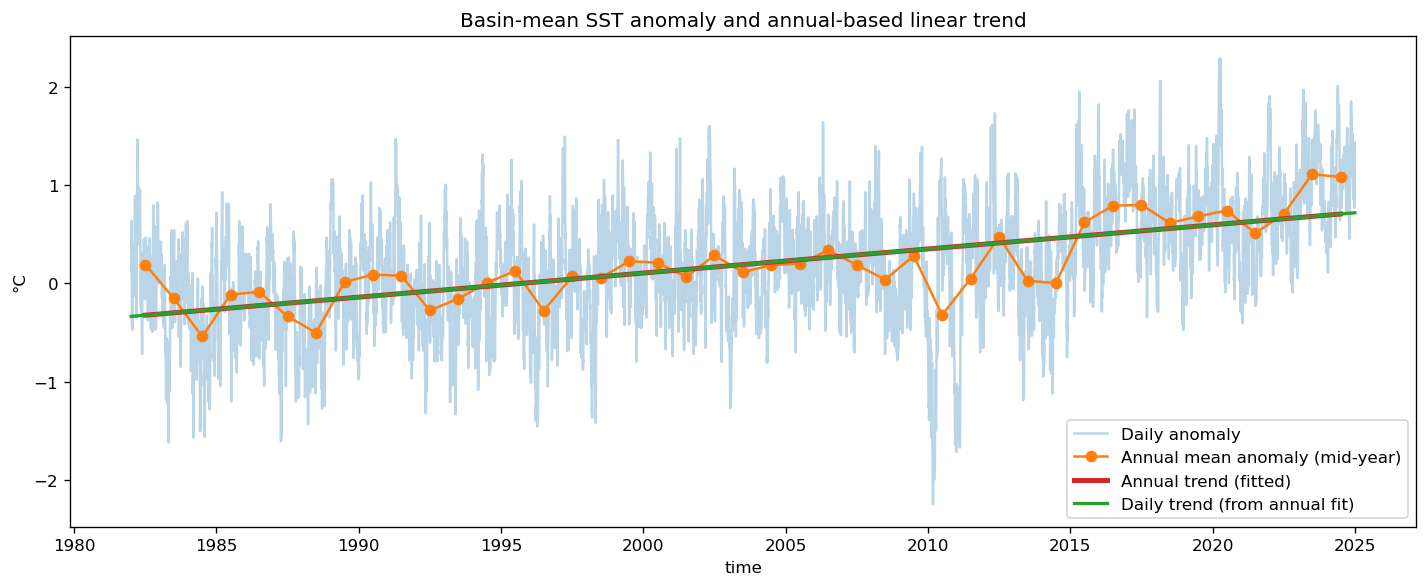

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(12, 5))

sst_basin_anom.plot(ax=ax, color='C0', alpha=0.3, label="Daily anomaly")
sst_ann_mid.plot(ax=ax, color='C1', marker='o', label="Annual mean anomaly (mid-year)")
trend_ann.plot(ax=ax, color='C3', lw=3, label="Annual trend (fitted)")
sst_basin_trend.plot(ax=ax, color='C2', lw=2, label="Daily trend (from annual fit)")

ax.set_title("Basin-mean SST anomaly and annual-based linear trend")
ax.set_ylabel("°C")
ax.legend()
plt.tight_layout()
plt.show()

/var/folders/fg/9b9hyhcj143_m75qvt409pp80000gp/T/ipykernel_83883/2915144032.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


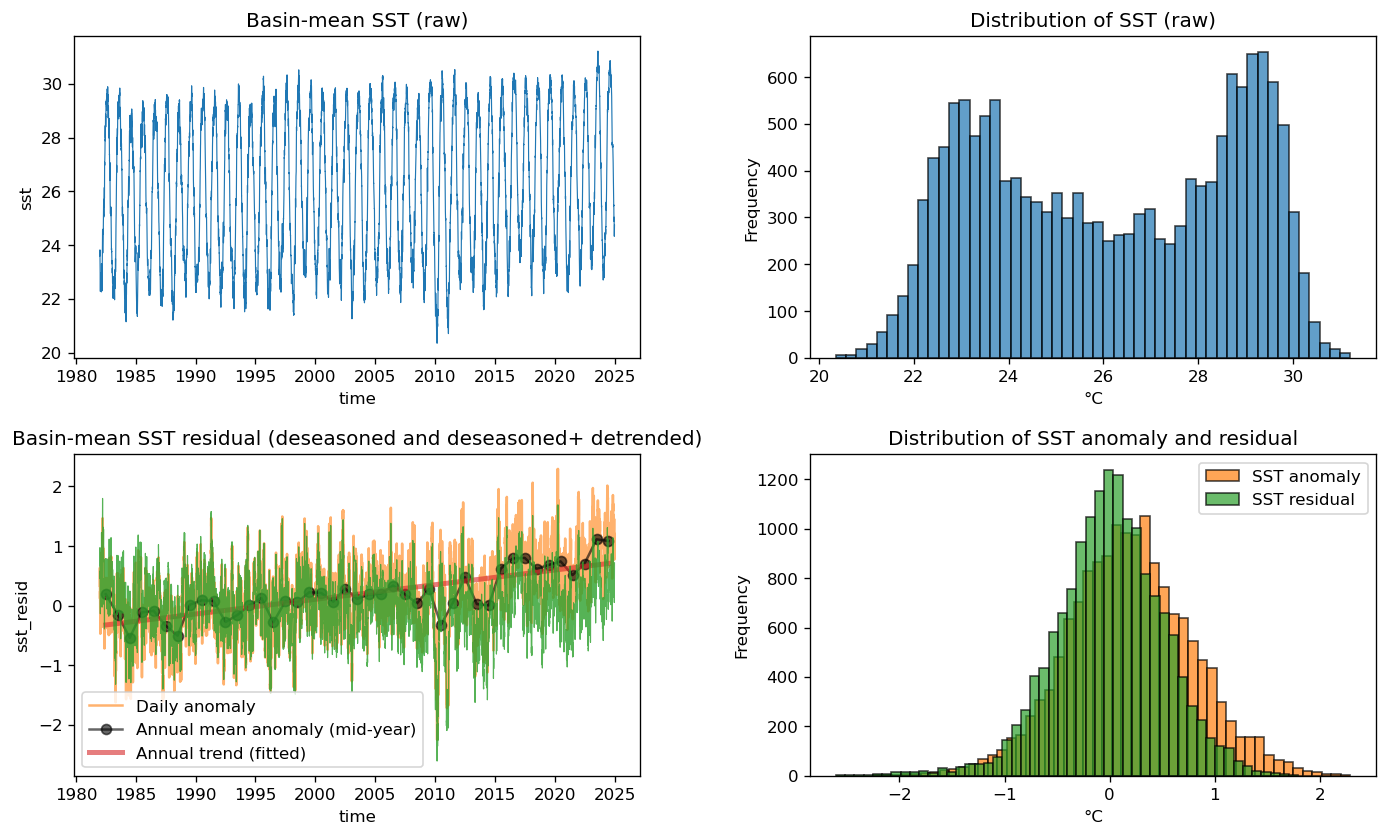

In [6]:
fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

# 时间序列图
ax1 = fig.add_subplot(gs[0, 0])
sst_basin.plot(ax=ax1, color="C0", lw=0.7)
ax1.set_title("Basin-mean SST (raw)")

ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)
sst_basin_anom.plot(ax=ax2, color='C1', alpha=0.6, label="Daily anomaly")
sst_ann_mid.plot(ax=ax2, color='k', marker='o', alpha=0.6, label="Annual mean anomaly (mid-year)")
trend_ann.plot(ax=ax2, color='C3', lw=3, alpha=0.6, label="Annual trend (fitted)")
ax2.set_title("Basin-mean SST anomaly and annual-based linear trend")
ax2.set_ylabel("°C")
ax2.legend()

sst_basin_resid.plot(ax=ax2, color="C2", lw=0.7,alpha=0.8)
ax2.set_title("Basin-mean SST residual (deseasoned and deseasoned+ detrended)")

# 分布图
ax3 = fig.add_subplot(gs[0, 1])
sst_basin.plot.hist(ax=ax3, bins=50, color="C0", alpha=0.7, edgecolor='black')
ax3.set_title("Distribution of SST (raw)")
ax3.set_xlabel("°C")
ax3.set_ylabel("Frequency")

# 后两个变量的分布叠加在一起
ax4 = fig.add_subplot(gs[1, 1])
sst_basin_anom.plot.hist(ax=ax4, bins=50, color="C1", alpha=0.7, edgecolor='black', label="SST anomaly")
sst_basin_resid.plot.hist(ax=ax4, bins=50, color="C2", alpha=0.7, edgecolor='black', label="SST residual")
ax4.set_title("Distribution of SST anomaly and residual")
ax4.set_xlabel("°C")
ax4.set_ylabel("Frequency")
ax4.legend()
plt.tight_layout()

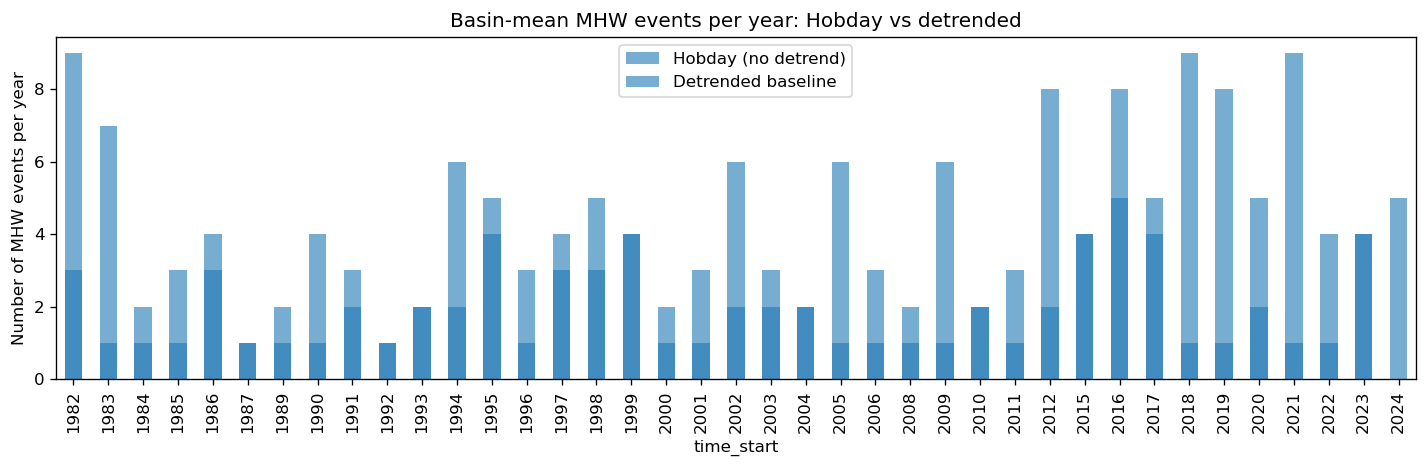

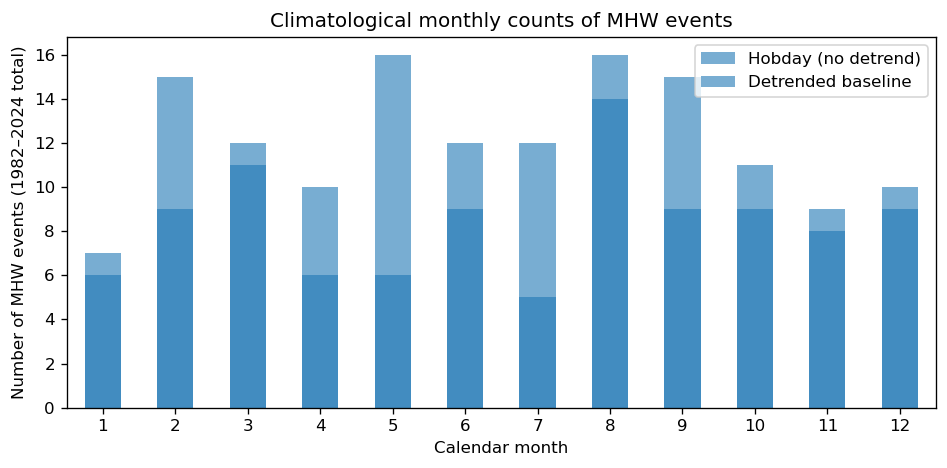

In [18]:
def yearly_counts(events_df, time_col="time_start"):
    years = events_df[time_col].dt.year
    return years.value_counts().sort_index()

def monthly_counts_climatology(events_df, time_col="time_start"):
    # 取 1–12 月
    mm = events_df[time_col].dt.month
    return mm.value_counts().sort_index()


# 年事件数
yc_raw  = yearly_counts(df_raw)
yc_detr = yearly_counts(df_detr)

fig, ax = plt.subplots(figsize=(12, 4))
yc_raw.plot(kind="bar", alpha=0.6, label="Hobday (no detrend)", ax=ax)
yc_detr.plot(kind="bar", alpha=0.6, label="Detrended baseline", ax=ax)
ax.set_ylabel("Number of MHW events per year")
ax.set_title("Basin-mean MHW events per year: Hobday vs detrended")
ax.legend()
plt.tight_layout()

# 月事件数
mc_raw_mclim  = monthly_counts_climatology(df_raw)
mc_detr_mclim = monthly_counts_climatology(df_detr)

fig, ax = plt.subplots(figsize=(8, 4))
mc_raw_mclim.plot(kind="bar", alpha=0.6, label="Hobday (no detrend)", ax=ax)
mc_detr_mclim.plot(kind="bar", alpha=0.6, label="Detrended baseline", ax=ax)

ax.set_xlabel("Calendar month")
ax.set_ylabel("Number of MHW events (1982–2024 total)")
ax.set_xticklabels(range(1, 13), rotation=0)
ax.set_title("Climatological monthly counts of MHW events")
ax.legend()
plt.tight_layout()
plt.show()


Intensity columns: ['intensity_max', 'intensity_max_relThresh', 'intensity_max_abs']
Intensity columns: ['intensity_mean', 'intensity_mean_relThresh', 'intensity_mean_abs']
Intensity columns: ['intensity_cumulative', 'intensity_cumulative_relThresh', 'intensity_cumulative_abs']


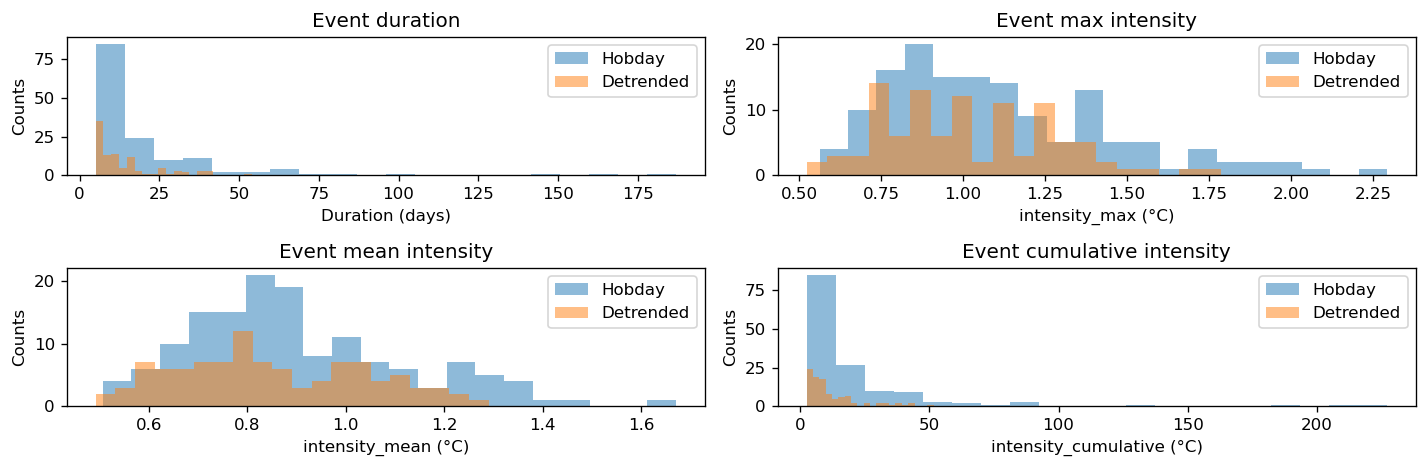

In [19]:
# 事件属性：持续时间 + 最大强度
fig, axes = plt.subplots(2, 2, figsize=(12, 4))

# 持续时间
axes[0, 0].hist(df_raw["duration"], bins=20, alpha=0.5, label="Hobday")
axes[0, 0].hist(df_detr["duration"], bins=20, alpha=0.5, label="Detrended")
axes[0, 0].set_xlabel("Duration (days)")
axes[0, 0].set_ylabel("Counts")
axes[0, 0].set_title("Event duration")
axes[0, 0].legend()

# 强度列名（取包含 "intensity_max" 的列）
int_cols = [c for c in df_raw.columns if "intensity_max" in c]
print("Intensity columns:", int_cols)
int_col = int_cols[0] if int_cols else "intensity_max"

axes[0, 1].hist(df_raw[int_col],  bins=20, alpha=0.5, label="Hobday")
axes[0, 1].hist(df_detr[int_col], bins=20, alpha=0.5, label="Detrended")
axes[0, 1].set_xlabel(f"{int_col} (°C)")
axes[0, 1].set_ylabel("Counts")
axes[0, 1].set_title("Event max intensity")
axes[0, 1].legend()

# 强度列名（取包含 "intensity_max" 的列）
int_cols = [c for c in df_raw.columns if "intensity_mean" in c]
print("Intensity columns:", int_cols)
int_col = int_cols[0] if int_cols else "intensity_mean"

axes[1,0].hist(df_raw[int_col],  bins=20, alpha=0.5, label="Hobday")
axes[1,0].hist(df_detr[int_col], bins=20, alpha=0.5, label="Detrended")
axes[1,0].set_xlabel(f"{int_col} (°C)")
axes[1,0].set_ylabel("Counts")
axes[1,0].set_title("Event mean intensity")
axes[1,0].legend()

# 强度列名（取包含 "intensity_max" 的列）
int_cols = [c for c in df_raw.columns if "intensity_cumulative" in c]
print("Intensity columns:", int_cols)
int_col = int_cols[0] if int_cols else "intensity_cumulative"

axes[1,1].hist(df_raw[int_col],  bins=20, alpha=0.5, label="Hobday")
axes[1,1].hist(df_detr[int_col], bins=20, alpha=0.5, label="Detrended")
axes[1,1].set_xlabel(f"{int_col} (°C)")
axes[1,1].set_ylabel("Counts")
axes[1,1].set_title("Event cumulative intensity")
axes[1,1].legend()

plt.tight_layout()